# Final Assignment Set D

## Machine Learning Lab, Summer Semester 2026, Uni Passau

### Rules:
    
   1. Submissions must be pushed to your fimgit in a folder dubbed `final-assignment`.
   2. Run your solutions in cells under the individual Tasks.
   3. For model implementations you are permitted to use *only* your library in its final state before the commencement of the exam.

Goodluck!

---

### Task 1: Prepare your data

   1. Download the two datasets and read them into memory.

   2. Analyse the data shape, targets and data characteristics.

   3. Apply any data cleaning, filling mechanisms if required

   4. Split the datasets into `train`, `valid` and `test` folds.

Dataset 1: [CLASSIFICATION] Mammographic Mass: https://archive.ics.uci.edu/dataset/161/mammographic+mass

Dataset 2: [REGRESSION] Airfoil Self-Noise: https://archive.ics.uci.edu/dataset/291/airfoil+self-noise



> Note: You may obtain the data any way you like from its UCI page

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# To make the mlab package available
sys.path.append("..")

from mlab.trees._decision_tree import DecisionTree
from mlab.regression._linear import LinearRegressor
from mlab.regression._logistic import LogisticRegression
from mlab.neural_networks._mlp import MLPRegressor

from mlab.evaluation._metrics import (
    accuracy_score,
    precision_recall_f1,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)

RANDOM_STATE = 42

In [2]:
mammographic_columns = [
    "bi_rads",
    "age",
    "shape",
    "margin",
    "density",
    "severity",
]

mammographic_df = pd.read_csv(
    "data/mammographic_masses.data",
    header=None,
    names=mammographic_columns,
    na_values="?",
)

mammographic_df.head()

,bi_rads,age,shape,margin,density,severity
0,5.0,67.0,3.0,5.0,3.0,1
1,4.0,43.0,1.0,1.0,NaN,1
2,5.0,58.0,4.0,5.0,3.0,1
3,4.0,28.0,1.0,1.0,3.0,0
4,5.0,74.0,1.0,5.0,NaN,1


In [3]:
print("Mammographic Mass dataset")
print("Shape:", mammographic_df.shape)

print("\nMissing values per column:")
print(mammographic_df.isna().sum())

print("\nTarget distribution:")
print(mammographic_df["severity"].value_counts().sort_index())

print("\nSummary statistics:")
display(mammographic_df.describe())

Mammographic Mass dataset
Shape: (961, 6)

Missing values per column:
bi_rads      2
age          5
shape       31
margin      48
density     76
severity     0
dtype: int64

Target distribution:
severity
0    516
1    445
Name: count, dtype: int64

Summary statistics:


,bi_rads,age,shape,margin,density,severity
count,959.000000,956.000000,930.000000,913.000000,885.000000,961.000000
mean,4.348279,55.487448,2.721505,2.796276,2.910734,0.463059
std,1.783031,14.480131,1.242792,1.566546,0.380444,0.498893
min,0.000000,18.000000,1.000000,1.000000,1.000000,0.000000
25%,4.000000,45.000000,2.000000,1.000000,3.000000,0.000000
50%,4.000000,57.000000,3.000000,3.000000,3.000000,0.000000
75%,5.000000,66.000000,4.000000,4.000000,3.000000,1.000000
max,55.000000,96.000000,4.000000,5.000000,4.000000,1.000000


In [4]:
# UCI describes BI-RADS assessment as non-predictive, so it is removed.
# Severity is the target variable and remains unchanged.
X_classification = mammographic_df.drop(
    columns=["bi_rads", "severity"]
)
y_classification = mammographic_df["severity"].astype(int)

print("Classification feature shape:", X_classification.shape)
print("Classification target shape:", y_classification.shape)

Classification feature shape: (961, 4)
Classification target shape: (961,)


In [5]:
airfoil_columns = [
    "frequency",
    "attack_angle",
    "chord_length",
    "free_stream_velocity",
    "displacement_thickness",
    "sound_pressure",
]

airfoil_df = pd.read_csv(
    "data/airfoil_self_noise.dat",
    sep=r"\s+",
    header=None,
    names=airfoil_columns,
)

airfoil_df.head()

,frequency,attack_angle,chord_length,free_stream_velocity,displacement_thickness,sound_pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [6]:
print("Airfoil Self-Noise dataset")
print("Shape:", airfoil_df.shape)

print("\nMissing values per column:")
print(airfoil_df.isna().sum())

print("\nSummary statistics:")
display(airfoil_df.describe())

Airfoil Self-Noise dataset
Shape: (1503, 6)

Missing values per column:
frequency                 0
attack_angle              0
chord_length              0
free_stream_velocity      0
displacement_thickness    0
sound_pressure            0
dtype: int64

Summary statistics:


,frequency,attack_angle,chord_length,free_stream_velocity,displacement_thickness,sound_pressure
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


In [7]:
X_regression = airfoil_df.drop(columns="sound_pressure")
y_regression = airfoil_df["sound_pressure"]

print("Regression feature shape:", X_regression.shape)
print("Regression target shape:", y_regression.shape)

Regression feature shape: (1503, 5)
Regression target shape: (1503,)


In [8]:
def split_train_validation_test(X, y, random_state=42, stratify=None):
    """
    Create fixed 70% training, 15% validation, and 15% test folds.

    The validation and test folds are each half of the 30% temporary split.
    Stratification is used only for classification to preserve class ratios.
    """
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=random_state,
        stratify=stratify,
    )

    temp_stratify = y_temp if stratify is not None else None

    X_validation, X_test, y_validation, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=random_state,
        stratify=temp_stratify,
    )

    return (
        X_train,
        X_validation,
        X_test,
        y_train,
        y_validation,
        y_test,
    )

In [9]:
(
    X_class_train,
    X_class_validation,
    X_class_test,
    y_class_train,
    y_class_validation,
    y_class_test,
) = split_train_validation_test(
    X_classification,
    y_classification,
    random_state=RANDOM_STATE,
    stratify=y_classification,
)

print("Classification split sizes")
print("Train:     ", X_class_train.shape)
print("Validation:", X_class_validation.shape)
print("Test:      ", X_class_test.shape)

Classification split sizes
Train:      (672, 4)
Validation: (144, 4)
Test:       (145, 4)


In [10]:
(
    X_reg_train,
    X_reg_validation,
    X_reg_test,
    y_reg_train,
    y_reg_validation,
    y_reg_test,
) = split_train_validation_test(
    X_regression,
    y_regression,
    random_state=RANDOM_STATE,
)

print("Regression split sizes")
print("Train:     ", X_reg_train.shape)
print("Validation:", X_reg_validation.shape)
print("Test:      ", X_reg_test.shape)

Regression split sizes
Train:      (1052, 5)
Validation: (225, 5)
Test:       (226, 5)


In [11]:
def impute_with_training_medians(X_train, X_validation, X_test):
    """
    Fill missing values with medians calculated from training features only.

    Using training medians avoids using information from validation or test data.
    """
    training_medians = X_train.median()

    X_train = X_train.fillna(training_medians)
    X_validation = X_validation.fillna(training_medians)
    X_test = X_test.fillna(training_medians)

    return X_train, X_validation, X_test

In [12]:
(
    X_class_train,
    X_class_validation,
    X_class_test,
) = impute_with_training_medians(
    X_class_train,
    X_class_validation,
    X_class_test,
)

classification_scaler = StandardScaler()

X_class_train_scaled = classification_scaler.fit_transform(X_class_train)
X_class_validation_scaled = classification_scaler.transform(X_class_validation)
X_class_test_scaled = classification_scaler.transform(X_class_test)

print("Remaining missing values in classification folds:")
print(np.isnan(X_class_train_scaled).sum())
print(np.isnan(X_class_validation_scaled).sum())
print(np.isnan(X_class_test_scaled).sum())

Remaining missing values in classification folds:
0
0
0


In [13]:
(
    X_reg_train,
    X_reg_validation,
    X_reg_test,
) = impute_with_training_medians(
    X_reg_train,
    X_reg_validation,
    X_reg_test,
)

regression_scaler = StandardScaler()

X_reg_train_scaled = regression_scaler.fit_transform(X_reg_train)
X_reg_validation_scaled = regression_scaler.transform(X_reg_validation)
X_reg_test_scaled = regression_scaler.transform(X_reg_test)

print("Remaining missing values in regression folds:")
print(np.isnan(X_reg_train_scaled).sum())
print(np.isnan(X_reg_validation_scaled).sum())
print(np.isnan(X_reg_test_scaled).sum())

Remaining missing values in regression folds:
0
0
0


### Task 2: Apply baseline models of your choice (1 classification + 1 regression) for each of the two datasets. Please note you cannot use models required in Task 4 as baselines.


```python
baseline = YourAlgorithm()
baseline.learn(features_train, labels_train)
```

## Task 2: Baseline models

I use a Decision Tree as the classification baseline and Linear Regression as
the regression baseline. These choices are different from the required Task 4
models: Logistic Regression and an Artificial Neural Network.

In [14]:
classification_baseline = DecisionTree(
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
)

classification_baseline.fit(
    X_class_train_scaled,
    y_class_train.to_numpy(),
)

In [15]:
regression_baseline = LinearRegressor()

regression_baseline.fit(
    X_reg_train_scaled,
    y_reg_train.to_numpy(),
)

### Task 3: Evaluate your baseline models on test set:
Use accuracy, precision and recall for classification, and R2 score and MAE/RMSE for regression
```python
baseline_predicted = model_baseline.infer(features_test)
evaluate_fn(baseline_predicted, labels_test)
```

In [16]:
baseline_class_predictions = classification_baseline.predict(
    X_class_test_scaled
)

baseline_accuracy = accuracy_score(
    y_class_test.to_numpy(),
    baseline_class_predictions,
)

baseline_precision, baseline_recall, baseline_f1 = precision_recall_f1(
    y_class_test.to_numpy(),
    baseline_class_predictions,
    average="macro",
)

baseline_matrix = confusion_matrix(
    y_class_test.to_numpy(),
    baseline_class_predictions,
)

print("Decision Tree baseline results")
print(f"Accuracy:  {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall:    {baseline_recall:.3f}")
print(f"Macro F1:  {baseline_f1:.3f}")
print("\nConfusion matrix:")
print(baseline_matrix)

Decision Tree baseline results
Accuracy:  0.793
Precision: 0.809
Recall:    0.801
Macro F1:  0.793

Confusion matrix:
[[54 24]
 [ 6 61]]


In [17]:
baseline_reg_predictions = regression_baseline.predict(X_reg_test_scaled)

baseline_mae = mean_absolute_error(
    y_reg_test.to_numpy(),
    baseline_reg_predictions,
)

baseline_rmse = root_mean_squared_error(
    y_reg_test.to_numpy(),
    baseline_reg_predictions,
)

baseline_r2 = r2_score(
    y_reg_test.to_numpy(),
    baseline_reg_predictions,
)

print("Linear Regression baseline results")
print(f"MAE:  {baseline_mae:.3f}")
print(f"RMSE: {baseline_rmse:.3f}")
print(f"R²:   {baseline_r2:.3f}")

Linear Regression baseline results
MAE:  3.642
RMSE: 4.675
R²:   0.509


### Task 4: Implement and train the following methods:

    a) Logistic Regression for classification 
    b) ANN for regression
    
- Use one fixed train-validation-test split consistently for all experiments
- Report the same metrics used for the baselines on the test set.

## Task 4: Required models

This task trains the required Logistic Regression classifier and MLP Regressor.

The same fixed training, validation, and test split from Task 1 is used for
all models. The validation set is not used here to select parameters yet;
hyperparameter optimisation is performed separately in Task 5.

In [18]:
# Initial Logistic Regression model.
# Feature scaling was already fitted using training data only.
logistic_model = LogisticRegression(
    learning_rate=0.05,
    n_iterations=1000,
)

logistic_model.fit(
    X_class_train_scaled,
    y_class_train.to_numpy(),
)

logistic_predictions = logistic_model.predict(X_class_test_scaled)

logistic_accuracy = accuracy_score(
    y_class_test.to_numpy(),
    logistic_predictions,
)

logistic_precision, logistic_recall, logistic_f1 = precision_recall_f1(
    y_class_test.to_numpy(),
    logistic_predictions,
    average="macro",
)

logistic_matrix = confusion_matrix(
    y_class_test.to_numpy(),
    logistic_predictions,
)

print("Initial Logistic Regression results")
print(f"Accuracy:  {logistic_accuracy:.3f}")
print(f"Precision: {logistic_precision:.3f}")
print(f"Recall:    {logistic_recall:.3f}")
print(f"Macro F1:  {logistic_f1:.3f}")
print("\nConfusion matrix:")
print(logistic_matrix)

Initial Logistic Regression results
Accuracy:  0.800
Precision: 0.807
Recall:    0.806
Macro F1:  0.800

Confusion matrix:
[[57 21]
 [ 8 59]]


In [19]:
# Initial ANN / MLP regression model.
# A small hidden network is sufficient for a first experiment.
mlp_model = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    lr=0.01,
    epochs=500,
    activation="relu",
    alpha=0.0001,
    random_state=RANDOM_STATE,
)

mlp_model.fit(
    X_reg_train_scaled,
    y_reg_train.to_numpy(),
)

mlp_predictions = mlp_model.predict(X_reg_test_scaled)

mlp_mae = mean_absolute_error(
    y_reg_test.to_numpy(),
    mlp_predictions,
)

mlp_rmse = root_mean_squared_error(
    y_reg_test.to_numpy(),
    mlp_predictions,
)

mlp_r2 = r2_score(
    y_reg_test.to_numpy(),
    mlp_predictions,
)

print("Initial MLP Regressor results")
print(f"MAE:  {mlp_mae:.3f}")
print(f"RMSE: {mlp_rmse:.3f}")
print(f"R²:   {mlp_r2:.3f}")

Initial MLP Regressor results
MAE:  5.863
RMSE: 6.885
R²:   -0.064


### Task 5: Hyperparameter Optimisation
- For each of the models implemented in Task 4, conduct a grid search in reasonable ranges to find an appropriate set of hyperparameters, and justify the choice.

```python
possible_hp_values = np.arange(1, 10, 0.1)
best_hp_value = None
best_f1_score = -np.infty
for hp_value in possible_hp_values:
    # 1. create a baseline classifier object with hp_value specified
    current_model = YourAlgorithm(hyperparam=hp_value)
    
    # 2. learn the classifier on the training set
    current_model.learn(features_train, labels_train)
    
    # 3. evaluate the model on the validation set
    prediction = current_model.infer(features_valid)
    
    f1_score = compute_f1(labels_valid, prediction)
    if f1_score > best_f1_score:
        best_f1_score = f1_score
        best_hp_value = hp_value

print("Found hyperparameter value", best_hp_value)
print("Best f1-score on validation set", best_f1_score)

test_model = YourAlgorithm(hyperparam=best_hp_value)
test_model.learn(features_train, labels_train)
prediction = test_model.infer(features_test)
test_f1_score = compute_f1(labels_test, prediction)
print("F1-Score on test set", test_f1_score)
```


## Task 5: Hyperparameter optimisation

Hyperparameters are selected using the validation set only.

For Logistic Regression, I maximise macro F1-score because it gives equal
importance to both classes. For the MLP Regressor, I minimise RMSE because it
penalises larger prediction errors more strongly than MAE.

The test set is not used during grid search. It is evaluated only after the
best validation configuration has been selected.

In [20]:
# A small grid is sufficient because the dataset is relatively small.
learning_rate_values = [0.001, 0.01, 0.05, 0.1]
iteration_values = [300, 600, 1000, 1500]

best_logistic_params = None
best_logistic_validation_f1 = -np.inf
logistic_grid_results = []

for learning_rate in learning_rate_values:
    for n_iterations in iteration_values:
        current_model = LogisticRegression(
            learning_rate=learning_rate,
            n_iterations=n_iterations,
        )

        current_model.fit(
            X_class_train_scaled,
            y_class_train.to_numpy(),
        )

        validation_predictions = current_model.predict(
            X_class_validation_scaled
        )

        _, _, validation_f1 = precision_recall_f1(
            y_class_validation.to_numpy(),
            validation_predictions,
            average="macro",
        )

        logistic_grid_results.append({
            "learning_rate": learning_rate,
            "n_iterations": n_iterations,
            "validation_macro_f1": validation_f1,
        })

        if validation_f1 > best_logistic_validation_f1:
            best_logistic_validation_f1 = validation_f1
            best_logistic_params = {
                "learning_rate": learning_rate,
                "n_iterations": n_iterations,
            }

logistic_results_df = pd.DataFrame(logistic_grid_results)
display(logistic_results_df.sort_values(
    "validation_macro_f1",
    ascending=False,
))

print("Best Logistic Regression parameters:", best_logistic_params)
print(f"Best validation macro F1: {best_logistic_validation_f1:.3f}")

,learning_rate,n_iterations,validation_macro_f1
7,0.010,1500,0.798601
14,0.100,1000,0.798601
13,0.100,600,0.798601
12,0.100,300,0.798601
11,0.050,1500,0.798601
10,0.050,1000,0.798601
9,0.050,600,0.798601
8,0.050,300,0.798601
15,0.100,1500,0.798601
5,0.010,600,0.798524


Best Logistic Regression parameters: {'learning_rate': 0.01, 'n_iterations': 1500}
Best validation macro F1: 0.799


In [21]:
# Train a fresh final model using the best validation configuration.
best_logistic_model = LogisticRegression(
    learning_rate=best_logistic_params["learning_rate"],
    n_iterations=best_logistic_params["n_iterations"],
)

best_logistic_model.fit(
    X_class_train_scaled,
    y_class_train.to_numpy(),
)

best_logistic_predictions = best_logistic_model.predict(
    X_class_test_scaled
)

best_logistic_accuracy = accuracy_score(
    y_class_test.to_numpy(),
    best_logistic_predictions,
)

(
    best_logistic_precision,
    best_logistic_recall,
    best_logistic_f1,
) = precision_recall_f1(
    y_class_test.to_numpy(),
    best_logistic_predictions,
    average="macro",
)

best_logistic_matrix = confusion_matrix(
    y_class_test.to_numpy(),
    best_logistic_predictions,
)

print("Tuned Logistic Regression test results")
print(f"Accuracy:  {best_logistic_accuracy:.3f}")
print(f"Precision: {best_logistic_precision:.3f}")
print(f"Recall:    {best_logistic_recall:.3f}")
print(f"Macro F1:  {best_logistic_f1:.3f}")
print("\nConfusion matrix:")
print(best_logistic_matrix)

Tuned Logistic Regression test results
Accuracy:  0.793
Precision: 0.802
Recall:    0.799
Macro F1:  0.793

Confusion matrix:
[[56 22]
 [ 8 59]]


In [22]:
hidden_layer_values = [
    (8,),
    (16,),
    (16, 8),
]

learning_rate_values = [0.001, 0.01, 0.03]
alpha_values = [0.0, 0.0001]

best_mlp_params = None
best_mlp_validation_rmse = np.inf
mlp_grid_results = []

for hidden_layer_sizes in hidden_layer_values:
    for learning_rate in learning_rate_values:
        for alpha in alpha_values:
            current_model = MLPRegressor(
                hidden_layer_sizes=hidden_layer_sizes,
                lr=learning_rate,
                epochs=500,
                activation="relu",
                alpha=alpha,
                random_state=RANDOM_STATE,
            )

            current_model.fit(
                X_reg_train_scaled,
                y_reg_train.to_numpy(),
            )

            validation_predictions = current_model.predict(
                X_reg_validation_scaled
            )

            validation_rmse = root_mean_squared_error(
                y_reg_validation.to_numpy(),
                validation_predictions,
            )

            mlp_grid_results.append({
                "hidden_layer_sizes": str(hidden_layer_sizes),
                "learning_rate": learning_rate,
                "alpha": alpha,
                "validation_rmse": validation_rmse,
            })

            if validation_rmse < best_mlp_validation_rmse:
                best_mlp_validation_rmse = validation_rmse
                best_mlp_params = {
                    "hidden_layer_sizes": hidden_layer_sizes,
                    "lr": learning_rate,
                    "alpha": alpha,
                }

mlp_results_df = pd.DataFrame(mlp_grid_results)
display(mlp_results_df.sort_values(
    "validation_rmse",
    ascending=True,
))

print("Best MLP parameters:", best_mlp_params)
print(f"Best validation RMSE: {best_mlp_validation_rmse:.3f}")

,hidden_layer_sizes,learning_rate,alpha,validation_rmse
12,"(16, 8)",0.001,0.0000,4.455945
13,"(16, 8)",0.001,0.0001,4.458973
9,"(16,)",0.010,0.0001,4.602969
7,"(16,)",0.001,0.0001,4.647722
6,"(16,)",0.001,0.0000,4.647874
8,"(16,)",0.010,0.0000,4.653105
0,"(8,)",0.001,0.0000,4.700660
1,"(8,)",0.001,0.0001,4.700717
2,"(8,)",0.010,0.0000,4.842271
3,"(8,)",0.010,0.0001,4.881686


Best MLP parameters: {'hidden_layer_sizes': (16, 8), 'lr': 0.001, 'alpha': 0.0}
Best validation RMSE: 4.456


In [23]:
# Train a fresh final MLP using the best validation configuration.
best_mlp_model = MLPRegressor(
    hidden_layer_sizes=best_mlp_params["hidden_layer_sizes"],
    lr=best_mlp_params["lr"],
    epochs=500,
    activation="relu",
    alpha=best_mlp_params["alpha"],
    random_state=RANDOM_STATE,
)

best_mlp_model.fit(
    X_reg_train_scaled,
    y_reg_train.to_numpy(),
)

best_mlp_predictions = best_mlp_model.predict(X_reg_test_scaled)

best_mlp_mae = mean_absolute_error(
    y_reg_test.to_numpy(),
    best_mlp_predictions,
)

best_mlp_rmse = root_mean_squared_error(
    y_reg_test.to_numpy(),
    best_mlp_predictions,
)

best_mlp_r2 = r2_score(
    y_reg_test.to_numpy(),
    best_mlp_predictions,
)

print("Tuned MLP Regressor test results")
print(f"MAE:  {best_mlp_mae:.3f}")
print(f"RMSE: {best_mlp_rmse:.3f}")
print(f"R²:   {best_mlp_r2:.3f}")

Tuned MLP Regressor test results
MAE:  3.162
RMSE: 4.188
R²:   0.606


### Hyperparameter choice

For Logistic Regression, I tested four learning rates and four iteration
counts. I selected `learning_rate = 0.01` and `n_iterations = 1500` because
this configuration achieved the highest validation macro F1-score of 0.799.

For the MLP Regressor, I tested three hidden-layer architectures, three
learning rates, and two L2 regularisation values. I selected
`hidden_layer_sizes = (16, 8)`, `lr = 0.001`, and `alpha = 0.0` because this
configuration achieved the lowest validation RMSE of 4.456.

The test set was used only for the final evaluation after selecting the
hyperparameters on the validation set.

### Task 6: Statistical/stability tests

- over multiple runs $r \geq 5, r\in\mathbb{N}$  randomly shuffle your training data
- split it into a train-test, e.g. 90% of the data is for training, 10% for testing
- Report the mean and standard deviation of the error/accuracy of your models over the multiple runs
- plot a boxplot of the stability of your model

## Task 6: Statistical stability tests

I evaluate model stability over 10 different random 90/10 training-test
splits. Each repetition fits imputation and scaling only on that repetition's
training data.

For classification I report accuracy. For regression I report RMSE. A small
standard deviation and a narrow boxplot indicate that the model is relatively
stable across different splits.

In [24]:
classification_stability_scores = []

for run in range(10):
    X_train_run, X_test_run, y_train_run, y_test_run = train_test_split(
        X_classification,
        y_classification,
        test_size=0.10,
        random_state=run,
        stratify=y_classification,
    )

    # Fit median imputation only on this run's training data.
    training_medians = X_train_run.median()
    X_train_run = X_train_run.fillna(training_medians)
    X_test_run = X_test_run.fillna(training_medians)

    # Fit scaling only on this run's training data.
    scaler = StandardScaler()
    X_train_run_scaled = scaler.fit_transform(X_train_run)
    X_test_run_scaled = scaler.transform(X_test_run)

    model = LogisticRegression(
        learning_rate=best_logistic_params["learning_rate"],
        n_iterations=best_logistic_params["n_iterations"],
    )

    model.fit(X_train_run_scaled, y_train_run.to_numpy())
    predictions = model.predict(X_test_run_scaled)

    accuracy = accuracy_score(y_test_run.to_numpy(), predictions)
    classification_stability_scores.append(accuracy)

print("Logistic Regression stability")
print(f"Mean accuracy: {np.mean(classification_stability_scores):.3f}")
print(f"Standard deviation: {np.std(classification_stability_scores):.3f}")
print("Individual accuracies:", np.round(classification_stability_scores, 3))

Logistic Regression stability
Mean accuracy: 0.793
Standard deviation: 0.043
Individual accuracies: [0.835 0.804 0.722 0.804 0.794 0.763 0.856 0.722 0.804 0.825]


In [25]:
regression_stability_scores = []

for run in range(10):
    X_train_run, X_test_run, y_train_run, y_test_run = train_test_split(
        X_regression,
        y_regression,
        test_size=0.10,
        random_state=run,
    )

    # This is safe even though Airfoil has no missing values.
    training_medians = X_train_run.median()
    X_train_run = X_train_run.fillna(training_medians)
    X_test_run = X_test_run.fillna(training_medians)

    scaler = StandardScaler()
    X_train_run_scaled = scaler.fit_transform(X_train_run)
    X_test_run_scaled = scaler.transform(X_test_run)

    model = MLPRegressor(
        hidden_layer_sizes=best_mlp_params["hidden_layer_sizes"],
        lr=best_mlp_params["lr"],
        epochs=500,
        activation="relu",
        alpha=best_mlp_params["alpha"],
        random_state=run,
    )

    model.fit(X_train_run_scaled, y_train_run.to_numpy())
    predictions = model.predict(X_test_run_scaled)

    rmse = root_mean_squared_error(y_test_run.to_numpy(), predictions)
    regression_stability_scores.append(rmse)

print("MLP Regressor stability")
print(f"Mean RMSE: {np.mean(regression_stability_scores):.3f}")
print(f"Standard deviation: {np.std(regression_stability_scores):.3f}")
print("Individual RMSE values:", np.round(regression_stability_scores, 3))

MLP Regressor stability
Mean RMSE: 3.813
Standard deviation: 0.486
Individual RMSE values: [4.176 3.637 4.018 2.84  3.997 3.581 3.292 4.715 3.931 3.947]


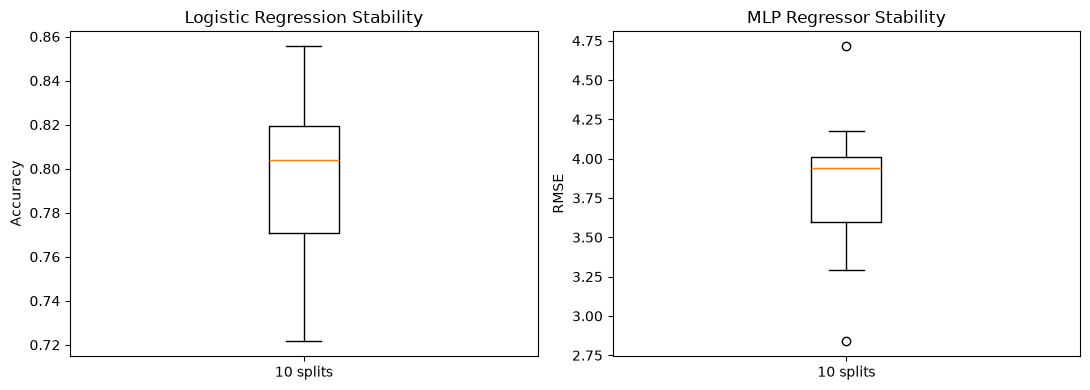

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].boxplot(classification_stability_scores)
axes[0].set_title("Logistic Regression Stability")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks([1])
axes[0].set_xticklabels(["10 splits"])

axes[1].boxplot(regression_stability_scores)
axes[1].set_title("MLP Regressor Stability")
axes[1].set_ylabel("RMSE")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["10 splits"])

plt.tight_layout()
plt.show()

### Stability interpretation

Across the 10 random 90/10 splits, Logistic Regression achieved mean accuracy
of 0.793 with a standard deviation of 0.043. Its accuracy varied between
0.722 and 0.856, so its performance changes moderately with the sampled split.

The MLP Regressor achieved mean RMSE of 3.813 with a standard deviation of
0.486. Its RMSE values ranged from 2.840 to 4.715. The MLP is reasonably
stable overall, although some splits produce noticeably better or worse
regression errors than others.

In [27]:
final_results = pd.DataFrame([
    {
        "Dataset": "Mammographic Mass",
        "Model": "Decision Tree baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "MAE": np.nan,
        "RMSE": np.nan,
        "R2": np.nan,
    },
    {
        "Dataset": "Mammographic Mass",
        "Model": "Tuned Logistic Regression",
        "Accuracy": best_logistic_accuracy,
        "Precision": best_logistic_precision,
        "Recall": best_logistic_recall,
        "Macro F1": best_logistic_f1,
        "MAE": np.nan,
        "RMSE": np.nan,
        "R2": np.nan,
    },
    {
        "Dataset": "Airfoil Self-Noise",
        "Model": "Linear Regression baseline",
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "Macro F1": np.nan,
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2,
    },
    {
        "Dataset": "Airfoil Self-Noise",
        "Model": "Tuned MLP Regressor",
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "Macro F1": np.nan,
        "MAE": best_mlp_mae,
        "RMSE": best_mlp_rmse,
        "R2": best_mlp_r2,
    },
])

display(final_results.round(3))

,Dataset,Model,Accuracy,Precision,Recall,Macro F1,MAE,RMSE,R2
0,Mammographic Mass,Decision Tree baseline,0.793,0.809,0.801,0.793,NaN,NaN,NaN
1,Mammographic Mass,Tuned Logistic Regression,0.793,0.802,0.799,0.793,NaN,NaN,NaN
2,Airfoil Self-Noise,Linear Regression baseline,NaN,NaN,NaN,NaN,3.642,4.675,0.509
3,Airfoil Self-Noise,Tuned MLP Regressor,NaN,NaN,NaN,NaN,3.162,4.188,0.606


## Conclusion

The Mammographic Mass dataset contained missing values in several input
features. I removed the `bi_rads` column and filled the remaining missing
values using medians calculated from training data only. The class distribution
was reasonably balanced, with 516 benign and 445 malignant cases.

For classification, the Decision Tree baseline achieved accuracy of 0.793 and
macro F1-score of 0.793. The tuned Logistic Regression model achieved accuracy
of 0.793 and macro F1-score of 0.793 on the same test set. Its selected
configuration was learning rate 0.01 with 1500 training iterations.

For regression, the Linear Regression baseline achieved MAE of 3.642, RMSE of
4.675, and R² of 0.509. The tuned MLP Regressor improved the result to MAE of
3.162, RMSE of 4.188, and R² of 0.606. The selected MLP used two hidden layers
with 16 and 8 neurons, learning rate 0.001, and no L2 regularisation.

The stability experiment showed mean Logistic Regression accuracy of 0.793
with standard deviation 0.043. The MLP achieved mean RMSE of 3.813 with
standard deviation 0.486. Therefore, both models have moderate variation when
the training and test samples are changed.